<a href="https://colab.research.google.com/github/aramrdz06/metodo-clasico-cuantico-Deutsch-Jozsa/blob/main/Proyecto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmo de Deutsch-Jozsa — Implementación en Qiskit

**Proyecto:** Fundamentos de computación cuántica — Determinación de paridad de una función booleana

**Autores:** Francisco Aram Rodriguez Garcia (07003963) · Santiago Cano Garcia (07003067)

Este notebook implementa el circuito cuántico del algoritmo de Deutsch-Jozsa delimitado en el avance de proyecto:
- **n = 3** qubits de entrada + **1** qubit auxiliar (ancilla) → 4 qubits en total.
- Backend: simulador ideal `AerSimulator` (equivalente a `qasm_simulator`).
- **1024 shots** por ejecución.
- Se prueban **4 oráculos**: 2 constantes y 2 balanceados (el avance exige como mínimo 1 constante y 2 balanceados).

> **Cómo usarlo:** ejecuta las celdas de arriba hacia abajo (menú *Entorno de ejecución → Ejecutar todo*). Cada celda de código va precedida de una explicación de lo que hace.

## 0. La idea en pocas palabras

**El problema.** Tenemos una función `f` escondida en una caja negra: le damos 3 bits y nos responde 0 o 1. Solo sabemos que es de uno de estos dos tipos:
- **Constante:** responde siempre lo mismo (siempre 0 o siempre 1).
- **Balanceada:** responde 0 en la mitad de las entradas y 1 en la otra mitad.

**La pregunta:** ¿de cuál tipo es?

| Método | Cuántas veces hay que "preguntarle" a la caja negra |
|---|---|
| Clásico | Hasta **5** (2ⁿ⁻¹ + 1, para n = 3), probando entradas una por una |
| Deutsch-Jozsa (cuántico) | Solo **1** |

**Cómo se lee la respuesta:** al final se miden los 3 qubits de entrada. Si sale `000` → la función es **constante**. Si sale cualquier otra cosa → es **balanceada**.

### Glosario rápido

| Término | Qué es, en palabras simples |
|---|---|
| **Qubit** | El "bit cuántico". Puede valer 0, 1 o una mezcla de ambos. |
| **Compuerta H (Hadamard)** | Pone un qubit en una mezcla 50/50 de 0 y 1 (*superposición*). Aplicada otra vez, hace que las mezclas se sumen o se cancelen (*interferencia*). |
| **Compuerta X** | Invierte el qubit: 0 → 1 y 1 → 0 (el NOT de siempre). |
| **Compuerta CX (CNOT)** | Invierte un qubit (el *objetivo*) solo si otro qubit (el *control*) vale 1. |
| **Oráculo `Uf`** | La caja negra que implementa `f`. Solo podemos usarla, no ver cómo está hecha por dentro. |
| **Ancilla** | Qubit auxiliar extra que ayuda al oráculo. No se mide. |
| **Shots** | Cuántas veces se repite el circuito completo (aquí, 1024). |
| **Counts** | El conteo de qué resultado salió en cada repetición. |

## Instalación

Google Colab no trae Qiskit instalado. La celda siguiente lo instala **solo si hace falta**, así que puedes ejecutarla siempre sin problema (la primera vez tarda un poco).

In [ ]:
# Intenta importar Qiskit Aer; si no está instalado (caso típico de Colab), lo instala.
try:
    import qiskit_aer
except ImportError:
    !pip install qiskit qiskit-aer pylatexenc matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.8 MB/s eta 0:00:00


## Importaciones

Aquí solo cargamos las herramientas que usaremos. Definimos también `N`, la cantidad de qubits de entrada.

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister  # para construir circuitos
from qiskit_aer import AerSimulator                                    # simulador cuántico ideal (sin ruido)
from qiskit.quantum_info import Statevector                            # calcula el estado cuántico exacto
from qiskit.visualization import plot_histogram, plot_bloch_multivector  # gráficas de resultados y esferas de Bloch
import matplotlib.pyplot as plt                                        # para acomodar varias gráficas juntas

N = 3  # qubits de entrada (según delimitación del avance)

## 1. Definición del oráculo Uf

El oráculo actúa sobre los `n` qubits de entrada y el qubit ancilla, usando **kickback de fase**:
- **Constante:** si f(x) = 1 para todo x, se aplica una puerta `X` a la ancilla (sin depender de los qubits de entrada). Si f(x) = 0, no se hace nada.
- **Balanceada:** se define f(x) como el XOR de un subconjunto de bits de x, indicado por una máscara. Cada bit en 1 de la máscara agrega una puerta `CX` (control = ese qubit de entrada, objetivo = ancilla). Esto garantiza que exactamente la mitad de las entradas den f(x)=0 y la otra mitad f(x)=1.

### ¿Cómo funciona la función `apply_oracle`?

**Numeración de qubits:** los qubits de entrada son el `0`, `1` y `2`; la ancilla es el qubit `n` (el `3`).

**Caso constante.** La ancilla es la "pantalla" donde se refleja el valor de `f`. Con `value=1` la volteamos con una `X` sin mirar la entrada, así que `f(x) = 1` para todas las x. Con `value=0` no hacemos nada, así que `f(x) = 0` para todas.

**Caso balanceado.** La *máscara* es un número binario que dice **qué bits de la entrada participan**. Por cada bit en 1 de la máscara, una `CX` voltea la ancilla cuando ese qubit de entrada vale 1. El resultado es que `f(x)` es el XOR de los bits elegidos. Por ejemplo, con la máscara `011` (bits 0 y 1):

| x (x₂x₁x₀) | 000 | 001 | 010 | 011 | 100 | 101 | 110 | 111 |
|---|---|---|---|---|---|---|---|---|
| f(x) = x₀ ⊕ x₁ | 0 | 1 | 1 | 0 | 0 | 1 | 1 | 0 |

Hay cuatro 0 y cuatro 1: es **balanceada**.

**El truco `(mask >> i) & 1`:** sirve para preguntar "¿el bit número `i` de la máscara vale 1?". Se recorre `i = 0, 1, 2` y solo donde la respuesta es sí se agrega una `CX`.

In [ ]:
def apply_oracle(qc, oracle_type, n, mask=None, value=0):
    """Aplica el oráculo Uf sobre los qubits [0..n-1] (entrada) y el qubit n (ancilla)."""
    if oracle_type == 'constant':
        if value == 1:
            qc.x(n)   # voltea la ancilla siempre -> f(x) = 1 para toda x
        # si value == 0, no se hace nada (identidad) -> f(x) = 0 para toda x
    elif oracle_type == 'balanced':
        if mask is None or mask == 0:
            # con máscara 0 no se agregaría ninguna puerta y la función saldría constante
            raise ValueError('Una función balanceada necesita una máscara distinta de 0')
        for i in range(n):              # revisa cada qubit de entrada: 0, 1, 2
            if (mask >> i) & 1:         # ¿el bit i de la máscara vale 1?
                qc.cx(i, n)             # sí: CX con control = qubit i, objetivo = ancilla
    else:
        raise ValueError('oracle_type debe ser "constant" o "balanced"')

## 2. Circuito completo del algoritmo

1. Ancilla en `|1⟩` (puerta `X`).
2. Hadamard en los `n` qubits de entrada y en la ancilla → superposición uniforme.
3. Aplicación del oráculo `Uf` (una única consulta).
4. Hadamard nuevamente sobre los `n` qubits de entrada → interferencia.
5. Medición de los `n` qubits de entrada.

### ¿Qué hace cada parte del código?

- **Registros:** `QuantumRegister(n + 1)` son los 4 qubits (3 de entrada + 1 ancilla). `ClassicalRegister(n)` son 3 bits normales donde se guardarán las mediciones; la ancilla no se mide, por eso son solo `n`.
- **Pasos 1 y 2 (preparación):** con `X` + `H` la ancilla queda en el estado `|−⟩`, y con `H` los qubits de entrada quedan en superposición de las 8 entradas posibles **a la vez**. Ese estado especial de la ancilla hace que el oráculo, en lugar de cambiar la ancilla, *marque con un signo −* las entradas donde `f(x) = 1` (eso es el kickback de fase).
- **Paso 3 (consulta):** aquí se llama a `apply_oracle` **una sola vez**. Esa es la ventaja frente al método clásico.
- **Paso 4 (interferencia):** el segundo `H` hace que las marcas del oráculo se sumen o se cancelen. Si la función es constante, todo se junta en `000`; si es balanceada, `000` se cancela por completo.
- **`qc.barrier()`** solo dibuja una línea para separar las etapas en el diagrama; no cambia el resultado.

In [ ]:
def deutsch_jozsa_circuit(n, oracle_type, mask=None, value=0):
    qr = QuantumRegister(n + 1, 'q')   # n qubits de entrada + 1 ancilla
    cr = ClassicalRegister(n, 'c')     # n bits clásicos para guardar las mediciones
    qc = QuantumCircuit(qr, cr)

    qc.x(n)              # ancilla -> |1>
    qc.h(range(n + 1))   # Hadamard a todos (entrada + ancilla)
    qc.barrier()

    apply_oracle(qc, oracle_type, n, mask=mask, value=value)   # 1 sola consulta a Uf
    qc.barrier()

    qc.h(range(n))        # Hadamard solo en los qubits de entrada
    qc.measure(range(n), range(n))   # mide qubit i y guarda el resultado en el bit clásico i
    return qc

## 3. Los tres oráculos de prueba

Según el criterio experimental de éxito del avance: **1 constante + 2 balanceados**, comparando la clasificación obtenida contra la esperada.

Aquí se prueban **4** (2 constantes y 2 balanceados), que cumple y supera ese mínimo. Cada oráculo es un diccionario con:
- `nombre`: cómo aparecerá en pantalla y en las gráficas.
- `type`, `value`, `mask`: los datos que recibe `apply_oracle` para construir la función.
- `esperado`: la respuesta correcta según la teoría, para poder comprobar si el circuito acierta.

> **Prueba tú mismo:** las máscaras `0b001` a `0b111` (cualquier número del 1 al 7) generan funciones balanceadas. Puedes agregar más oráculos a la lista.

In [ ]:
oracles = [
    {'nombre': 'Constante f(x) = 0', 'type': 'constant', 'value': 0, 'mask': None, 'esperado': 'Constante'},
    {'nombre': 'Constante f(x) = 1', 'type': 'constant', 'value': 1, 'mask': None, 'esperado': 'Constante'},
    {'nombre': 'Balanceada (máscara 011)', 'type': 'balanced', 'value': 0, 'mask': 0b011, 'esperado': 'Balanceada'},
    {'nombre': 'Balanceada (máscara 101)', 'type': 'balanced', 'value': 0, 'mask': 0b101, 'esperado': 'Balanceada'},
]

## 4. Ejecución en el simulador (AerSimulator, 1024 shots)

Para cada oráculo, el código hace lo siguiente:
1. Construye el circuito y lo ejecuta 1024 veces (*shots*) en el simulador.
2. Obtiene los `counts`: cuántas veces salió cada resultado (por ejemplo `{'000': 1024}`).
3. Calcula `prob_cero`, la fracción de veces que salió `000`.
4. **Clasifica:** si `000` salió en al menos el 95 % de los casos → *Constante*; si no → *Balanceada*. El 95 % es el criterio experimental de éxito del avance.
5. Compara con la respuesta esperada y escribe **OK** o **FALLA**.

> **Nota:** Qiskit escribe los resultados de derecha a izquierda, es decir, el qubit 0 es el dígito de más a la derecha.

In [ ]:
backend = AerSimulator()   # simulador ideal (sin ruido)
resultados = []            # aquí guardaremos todo para usarlo en las celdas siguientes

for o in oracles:
    # 1) construir y ejecutar el circuito
    qc = deutsch_jozsa_circuit(N, o['type'], mask=o['mask'], value=o['value'])
    job = backend.run(qc, shots=1024)
    counts = job.result().get_counts()          # ej. {'000': 1024}

    # 2) probabilidad de obtener |000>
    estado_cero = '0' * N                       # '000'
    prob_cero = counts.get(estado_cero, 0) / 1024   # si '000' nunca salió, cuenta como 0

    # 3) clasificación según el criterio del avance (>= 95 % en |000>)
    clasificacion = 'Constante' if prob_cero >= 0.95 else 'Balanceada'

    resultados.append({'nombre': o['nombre'], 'counts': counts, 'prob_cero': prob_cero,
                        'clasificacion': clasificacion, 'esperado': o['esperado'], 'circuito': qc})

    # 4) mostrar el resultado en una línea
    print(f"{o['nombre']:35s} | P(|000>) = {prob_cero:.4f} | "
          f"clasificación = {clasificacion:11s} | esperado = {o['esperado']:11s} | "
          f"{'OK' if clasificacion == o['esperado'] else 'FALLA'}")

Constante f(x) = 0                  | P(|000>) = 1.0000 | clasificación = Constante   | esperado = Constante   | OK
Constante f(x) = 1                  | P(|000>) = 1.0000 | clasificación = Constante   | esperado = Constante   | OK
Balanceada (máscara 011)            | P(|000>) = 0.0000 | clasificación = Balanceada  | esperado = Balanceada  | OK
Balanceada (máscara 101)            | P(|000>) = 0.0000 | clasificación = Balanceada  | esperado = Balanceada  | OK


### ¿Qué deberías ver?

| Oráculo | P(\|000⟩) | Clasificación | Estado |
|---|---|---|---|
| Constante f(x) = 0 | 1.0000 | Constante | OK |
| Constante f(x) = 1 | 1.0000 | Constante | OK |
| Balanceada (máscara 011) | 0.0000 | Balanceada | OK |
| Balanceada (máscara 101) | 0.0000 | Balanceada | OK |

Las cuatro líneas deben terminar en **OK**. Como el simulador es ideal (sin ruido), los resultados son exactos: 100 % o 0 %.

### Diagrama del circuito

Cómo leer el dibujo: cada línea horizontal es un qubit (`q_0` a `q_3`; `q_3` es la ancilla) y la línea `c` de abajo son los bits clásicos. Se lee de izquierda a derecha:
- Cajas **X** y **H**: las compuertas X y Hadamard.
- Punto ● unido con **⊕**: una compuerta `CX` (el punto es el control y el ⊕ el objetivo, la ancilla). Son las que forman el oráculo balanceado.
- Icono de medidor: la medición, que guarda el resultado en el bit clásico.
- Las bandas grises verticales son las `barrier`, que solo separan las etapas.

Se dibuja el oráculo balanceado (máscara 011); por eso se ven dos `CX`.

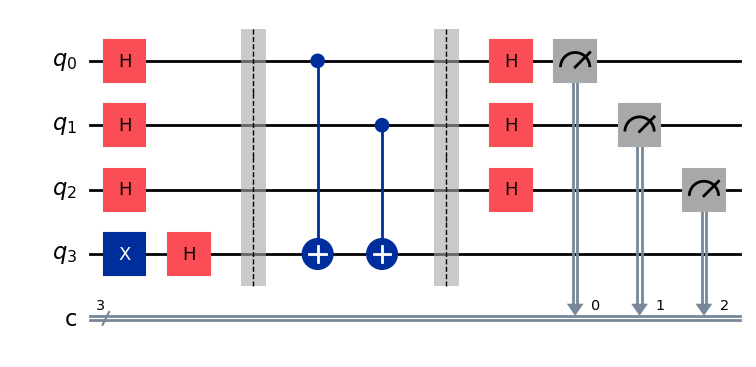

In [ ]:
# Diagrama del circuito (usar cualquiera de los oráculos, ej. el balanceado)
resultados[2]['circuito'].draw('mpl')

### Histogramas de resultados

Cada gráfica muestra cuántas veces salió cada resultado de las 1024 repeticiones, una gráfica por oráculo (en el mismo orden de la lista, con su nombre arriba).
- **Oráculos constantes:** una sola barra, en `000`, con 1024.
- **Oráculos balanceados:** una sola barra también, pero **nunca en `000`**. Sale el valor de la máscara (`011` y `101`), porque en este tipo de función el resultado coincide con los bits elegidos. Lo importante para el algoritmo es que sea distinto de `000`.

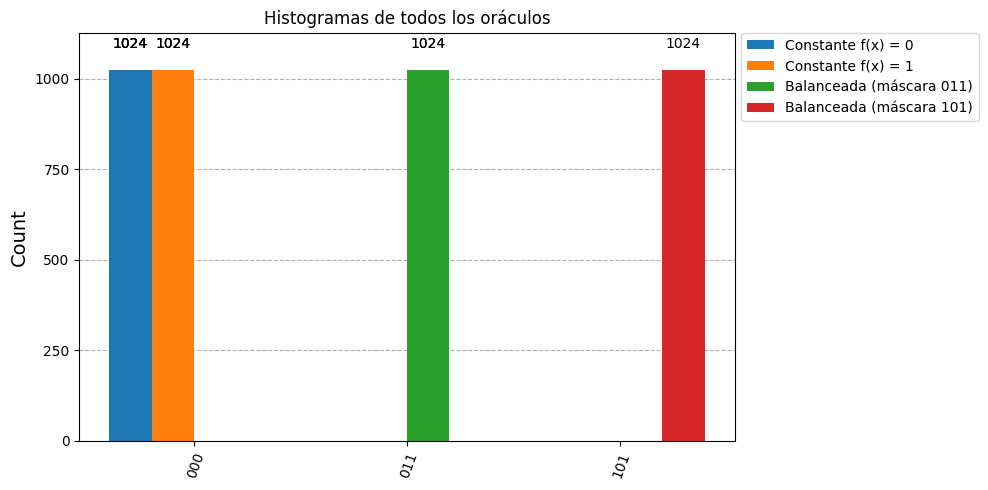

In [ ]:
# Obtener los counts y nombres de todos los oráculos
counts = [r['counts'] for r in resultados]
nombres = [r['nombre'] for r in resultados]

# Una sola gráfica
fig, ax = plt.subplots(figsize=(10, 5))

plot_histogram(
    counts,
    ax=ax,
    legend=nombres,
    bar_labels=True
)

ax.set_title("Histogramas de todos los oráculos")

plt.tight_layout()
plt.show()

## 5. Esferas de Bloch antes de medir

Se calcula el vector de estado (sin medición) justo antes de la medición final, para visualizar la superposición/interferencia en cada qubit de entrada.

### ¿Cómo se leen?

La esfera de Bloch es una forma de dibujar el estado de **un** qubit: el polo norte es `|0⟩`, el polo sur es `|1⟩` y los puntos intermedios son mezclas de ambos. Por cada oráculo aparecen 4 esferas (`q0` a `q3`). Deberías ver:
- **Oráculos constantes:** los tres qubits de entrada en el polo norte (`|0⟩`), que es justo el `000` que se mide.
- **Oráculos balanceados:** los qubits que están en 1 en la máscara quedan en el polo sur (`|1⟩`) y el resto en el norte. Por eso el resultado nunca es `000`.
- **Ancilla (`q3`):** siempre apunta al mismo punto del ecuador (estado `|−⟩`). Es el qubit auxiliar que permite el kickback de fase.

### ¿Qué hace el código?

- `circuito_sin_medir` es el mismo circuito de antes, pero **sin** la medición (y sin `barrier`), porque para calcular el estado exacto no se debe medir.
- `Statevector.from_instruction(qc_sv)` calcula matemáticamente el estado de los 4 qubits (no usa shots).
- `plot_bloch_multivector` dibuja una esfera por qubit, y `display(...)` la muestra en pantalla.

Constante f(x) = 0


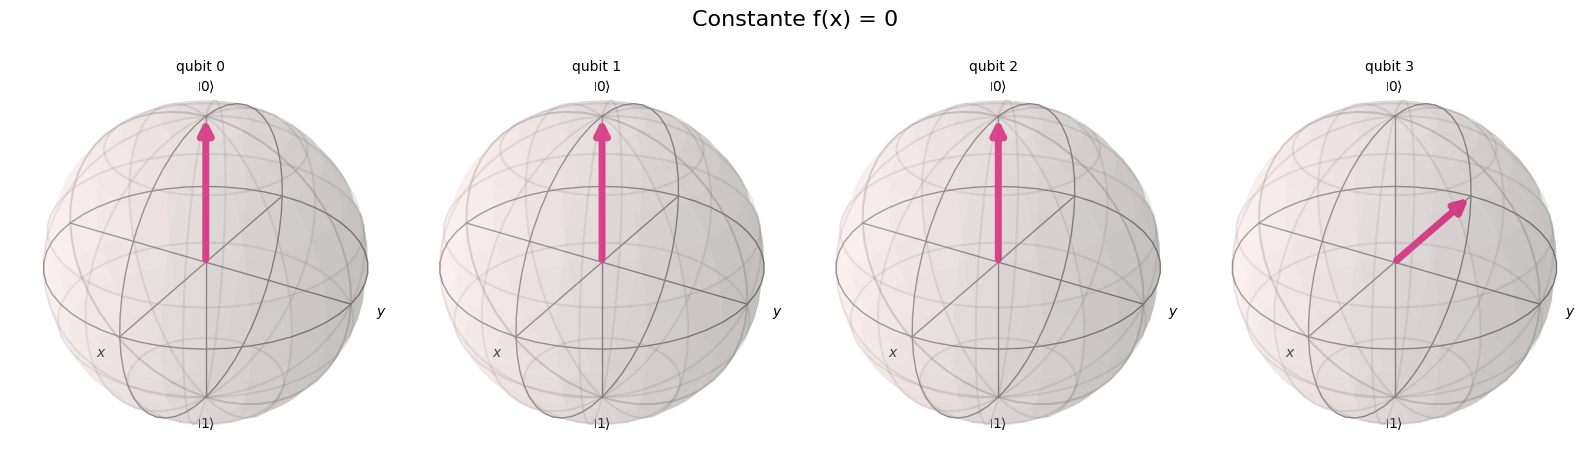

Constante f(x) = 1


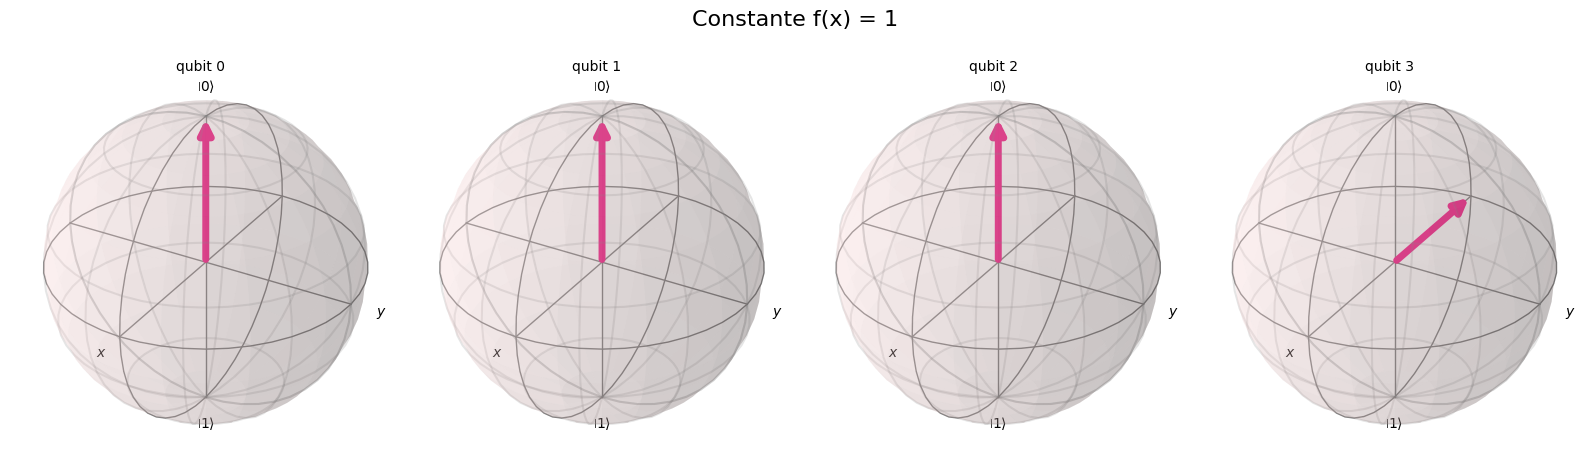

Balanceada (máscara 011)


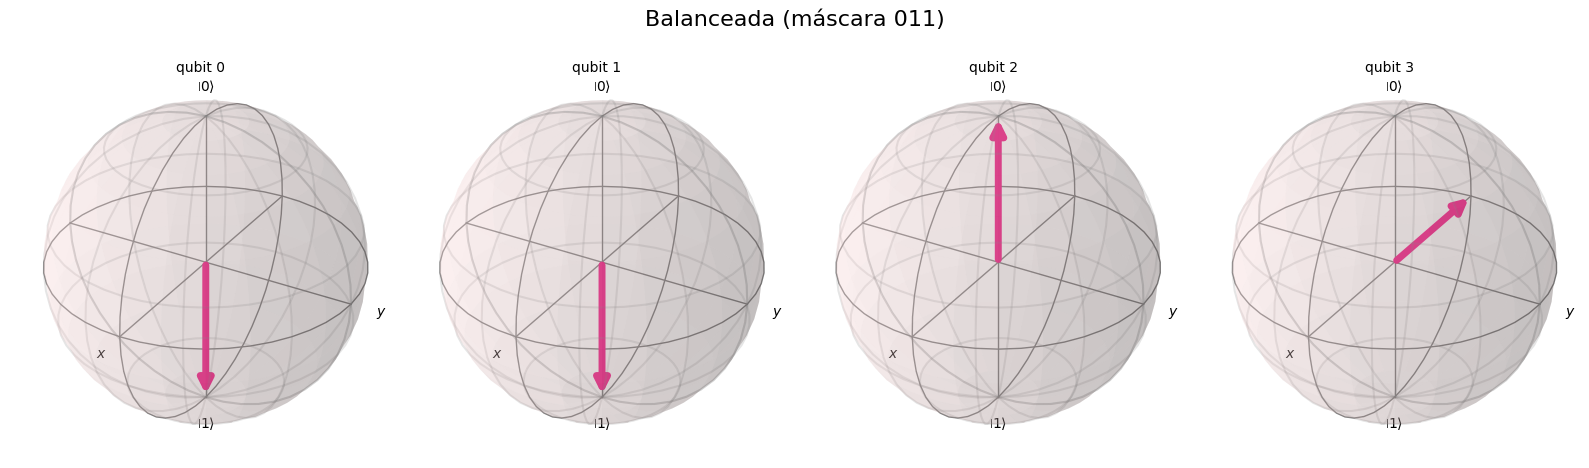

Balanceada (máscara 101)


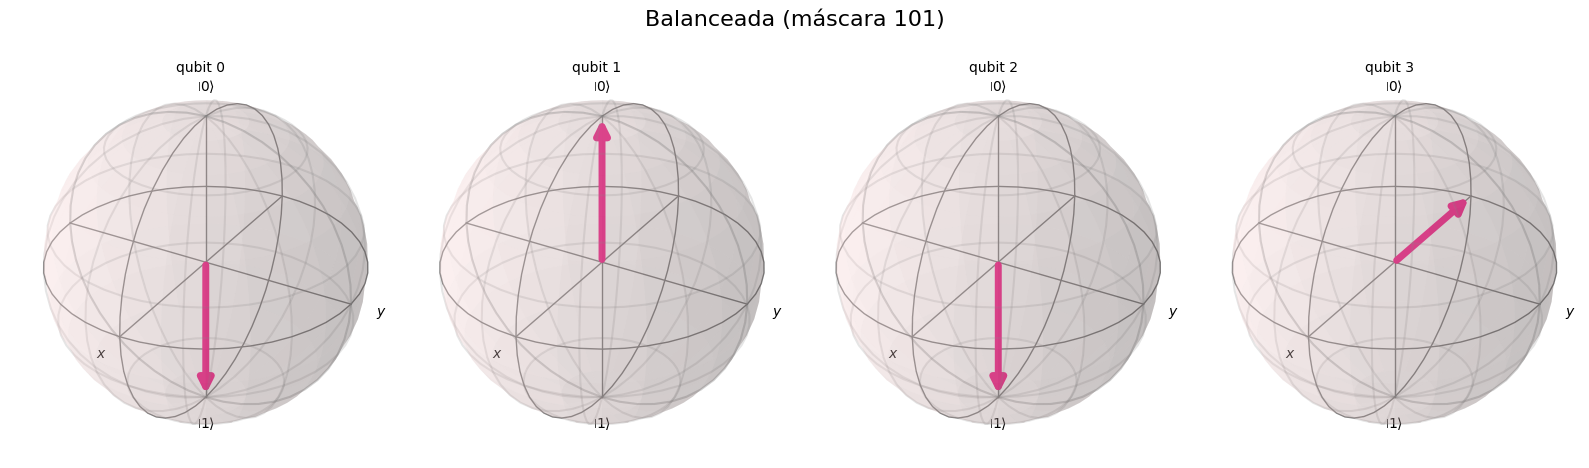

In [ ]:
def circuito_sin_medir(n, oracle_type, mask=None, value=0):
    qr = QuantumRegister(n + 1, 'q')
    qc = QuantumCircuit(qr)          # sin registro clásico: no habrá medición
    qc.x(n)
    qc.h(range(n + 1))
    apply_oracle(qc, oracle_type, n, mask=mask, value=value)
    qc.h(range(n))
    return qc

for o in oracles:
    qc_sv = circuito_sin_medir(N, o['type'], mask=o['mask'], value=o['value'])
    state = Statevector.from_instruction(qc_sv)   # estado exacto justo antes de medir
    print(o['nombre'])
    display(plot_bloch_multivector(state, title=o['nombre']))

## 6. Verificación de los criterios de éxito

- ✅ Una única consulta al oráculo `Uf` (verificable en `apply_oracle`, llamada una sola vez por circuito).
- ✅ Oráculo constante → P(|000⟩) ≥ 0.95 con 1024 shots.
- ✅ Oráculo balanceado → P(|000⟩) nunca domina (idealmente 0).
- ✅ Coincide la clasificación (constante/balanceada) para los 3+ oráculos probados contra lo esperado teóricamente.

*Dónde se comprueba cada uno:* la consulta única en `deutsch_jozsa_circuit` (llama a `apply_oracle` una vez); los otros tres en la tabla de resultados de la sección 4 (columnas `P(|000>)` y `OK`).

## 7. Comparación con el método clásico

El método clásico (implementado por separado en HTML/JavaScript, ver anexo del expediente) requiere en el peor caso hasta 2ⁿ⁻¹ + 1 = 5 consultas para n = 3. El algoritmo de Deutsch-Jozsa, verificado arriba, resuelve el mismo problema con **una única consulta**, para cualquiera de los oráculos probados.

## Conclusión

Los resultados obtenidos en el simulador ideal (`AerSimulator`, 1024 shots) confirman de forma experimental la ventaja teórica del algoritmo de Deutsch-Jozsa descrita en el avance de proyecto: con una sola consulta al oráculo `Uf`, el circuito determina con certeza si la función es constante o balanceada (P(|000⟩) = 1 para las constantes y 0 para las balanceadas en el simulador ideal, cuando el criterio pedía P ≥ 0.95), frente a las hasta 2ⁿ⁻¹ + 1 consultas que requeriría el método clásico equivalente.